In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("IMDb movies.csv", low_memory=False)
df.head()

,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894,1894-10-09,Romance,45,USA,NaN,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,12/26/1906,"Biography, Crime, Drama",70,Australia,NaN,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,"$2,250",NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,8/19/1911,Drama,53,"Germany, Denmark",NaN,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912,11/13/1912,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,"$45,000",NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911,3/6/1911,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


In [4]:
df_lr = df[['year', 'duration']].dropna()
df_lr.head()

,year,duration
0,1894,45
1,1906,70
2,1911,53
3,1912,100
4,1911,68


In [5]:
X = df_lr[['year']]
y = df_lr['duration']

In [6]:
df_lr['year'] = pd.to_numeric(df_lr['year'], errors='coerce')
df_lr['duration'] = pd.to_numeric(df_lr['duration'], errors='coerce')

df_lr = df_lr.dropna()

X = df_lr[['year']]
y = df_lr['duration']

In [7]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = model.predict(X)


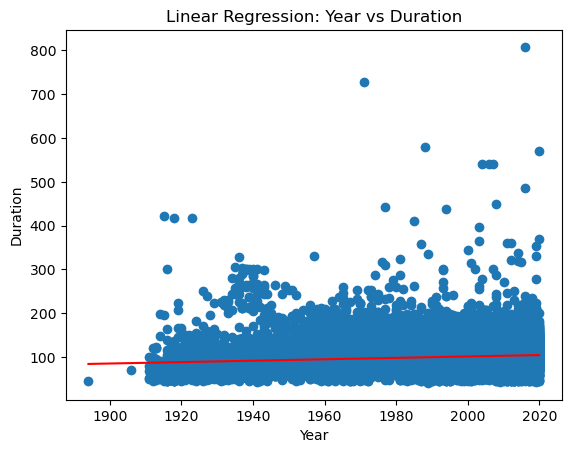

In [9]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')

plt.xlabel("Year")
plt.ylabel("Duration")
plt.title("Linear Regression: Year vs Duration")

plt.show()

In [10]:
df_kmeans = df[['year', 'duration']].dropna()

In [11]:
df_kmeans['year'] = pd.to_numeric(df_kmeans['year'], errors='coerce')
df_kmeans['duration'] = pd.to_numeric(df_kmeans['duration'], errors='coerce')

df_kmeans = df_kmeans.dropna()
df_kmeans.head()

,year,duration
0,1894.0,45
1,1906.0,70
2,1911.0,53
3,1912.0,100
4,1911.0,68


In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_kmeans)

In [13]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(scaled_data)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [14]:
clusters = kmeans.labels_

In [15]:
df_kmeans['cluster'] = clusters

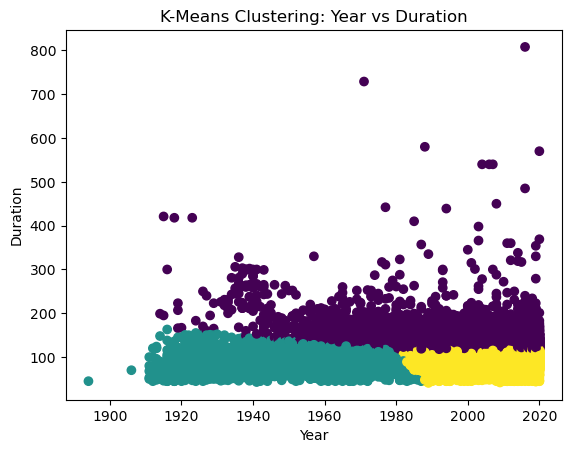

In [16]:
plt.scatter(df_kmeans['year'], df_kmeans['duration'], c=df_kmeans['cluster'])
plt.xlabel("Year")
plt.ylabel("Duration")
plt.title("K-Means Clustering: Year vs Duration")
plt.show()

In [17]:
df = df.dropna(subset=['duration', 'votes', 'year',
                       'reviews_from_users', 'reviews_from_critics'])

In [18]:
df["popularity_bin"] = pd.qcut(
    df["votes"],
    q=3,
    labels=["low_popularity", "medium_popularity", "high_popularity"]
)

In [19]:
X = df[['duration', 'votes', 'year',
        'reviews_from_users', 'reviews_from_critics']]

y = df['popularity_bin']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
print(X.isnull().sum())
print(y.isnull().sum())
print(X.dtypes)
print(X.head())
print(y.head())

duration                0
votes                   0
year                    0
reviews_from_users      0
reviews_from_critics    0
dtype: int64
0
duration                  int64
votes                     int64
year                     object
reviews_from_users      float64
reviews_from_critics    float64
dtype: object
   duration  votes  year  reviews_from_users  reviews_from_critics
0        45    154  1894                 1.0                   2.0
1        70    589  1906                 7.0                   7.0
2        53    188  1911                 5.0                   2.0
3       100    446  1912                25.0                   3.0
4        68   2237  1911                31.0                  14.0
0       low_popularity
1    medium_popularity
2       low_popularity
3    medium_popularity
4      high_popularity
Name: popularity_bin, dtype: category
Categories (3, object): ['low_popularity' < 'medium_popularity' < 'high_popularity']


In [22]:
X = df[['duration', 'votes', 'year', 'reviews_from_users', 'reviews_from_critics']]
y = df['popularity_bin']

X = X.apply(pd.to_numeric, errors='coerce')
temp = pd.concat([X, y], axis=1).dropna()

X = temp[['duration', 'votes', 'year', 'reviews_from_users', 'reviews_from_critics']]
y = temp['popularity_bin']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


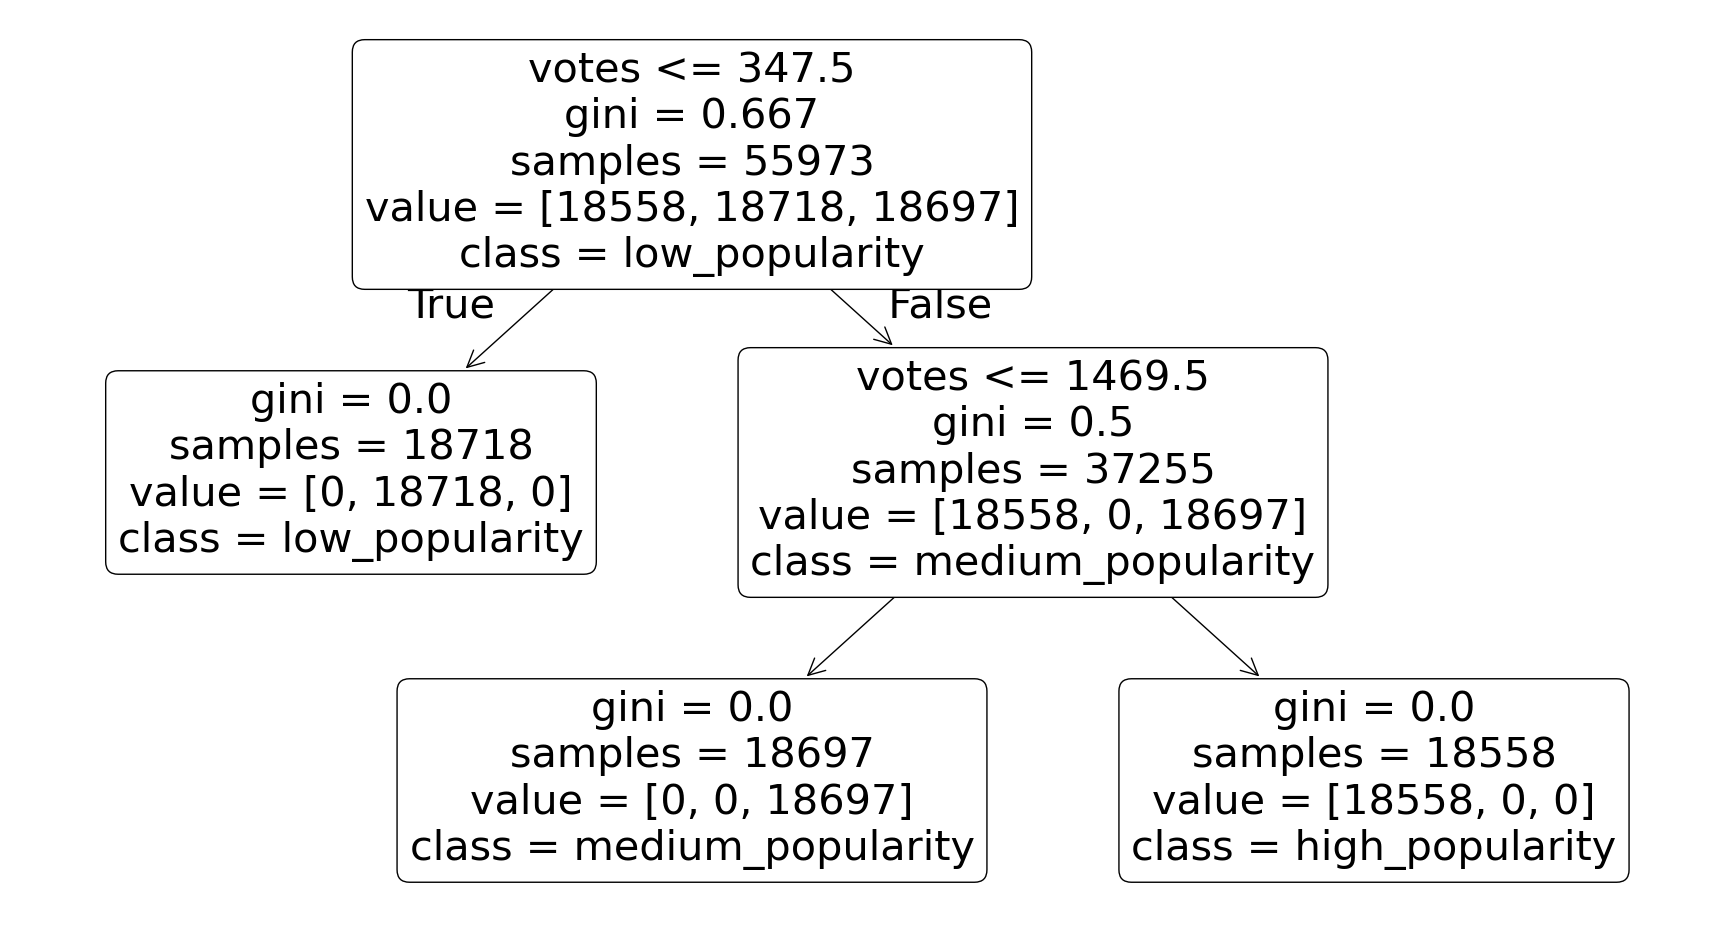

In [24]:
plt.figure(figsize=(22, 12))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    rounded=True
)
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


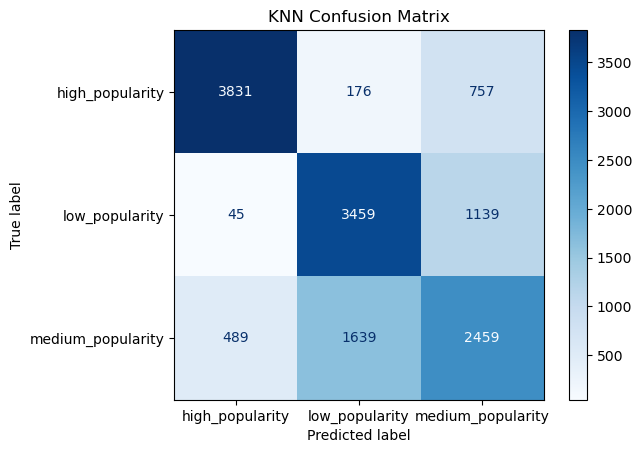

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test, cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

In [30]:
import joblib

joblib.dump(model, 'phase3_app/model.pkl')
print("Model saved!")

Model saved!
